Model Building and Evaluation

In this stage, different classification algorithms are trained and evaluated to predict movie success categories: Hit, Average, and Flop.

The models are compared using performance metrics such as accuracy, confusion matrix, precision, recall, F1-score, and classification report.

The classification models considered in this project include:

- Logistic Regression
- Decision Tree Classifier
- Random Forest Classifier
- Gradient Boosting / XGBoost

The objective is to compare the performance of different classification algorithms and understand their ability to predict movie success.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("cleaned_movie_data.csv")

In [5]:
df.shape

(4998, 28)

In [6]:
df.head()

,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,...,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes,classify
0,Color,James Cameron,723.0,178.0,0.0,855.0,Joel David Moore,1000.0,760505847.0,Action|Adventure|Fantasy|Sci-Fi,...,English,USA,PG-13,237000000.0,2009.0,936.0,7.9,1.78,33000,hit
1,Color,Gore Verbinski,302.0,169.0,563.0,1000.0,Orlando Bloom,40000.0,309404152.0,Action|Adventure|Fantasy,...,English,USA,PG-13,300000000.0,2007.0,5000.0,7.1,2.35,0,hit
2,Color,Sam Mendes,602.0,148.0,0.0,161.0,Rory Kinnear,11000.0,200074175.0,Action|Adventure|Thriller,...,English,UK,PG-13,245000000.0,2015.0,393.0,6.8,2.35,85000,hit
3,Color,Christopher Nolan,813.0,164.0,22000.0,23000.0,Christian Bale,27000.0,448130642.0,Action|Thriller,...,English,USA,PG-13,250000000.0,2012.0,23000.0,8.5,2.35,164000,hit
4,unknown,Doug Walker,110.0,103.0,131.0,369.0,Rob Walker,131.0,25445749.0,Documentary,...,unknown,unknown,unknown,20000000.0,2005.0,12.0,7.1,2.35,0,hit


In [6]:
df.columns

Index(['color', 'director_name', 'num_critic_for_reviews', 'duration',
       'director_facebook_likes', 'actor_3_facebook_likes', 'actor_2_name',
       'actor_1_facebook_likes', 'gross', 'genres', 'actor_1_name',
       'movie_title', 'num_voted_users', 'cast_total_facebook_likes',
       'actor_3_name', 'facenumber_in_poster', 'plot_keywords',
       'num_user_for_reviews', 'language', 'country', 'content_rating',
       'budget', 'title_year', 'actor_2_facebook_likes', 'imdb_score',
       'aspect_ratio', 'movie_facebook_likes', 'classify'],
      dtype='str')

Applying Selected Features

Based on the correlation and multicollinearity analysis performed during feature engineering, `actor_1_facebook_likes` is removed because it showed a very strong correlation with `cast_total_facebook_likes`.

The IMDb score is excluded from the input features because it was used to create the target variable and including it would cause target leakage. Movie title is also excluded because it acts primarily as an identifier.

High-cardinality categorical features such as director_name, actor_1_name, actor_2_name, actor_3_name, and plot_keywords were also excluded from the model inputs because they contain a large number of unique values. Direct label encoding of these features would assign arbitrary numerical values to names and keywords, which may not represent meaningful relationships and could reduce the model's ability to generalize.

In [8]:
df.drop("actor_1_facebook_likes", axis=1, inplace=True)

In [9]:
X = df.drop([
    "classify",
    "imdb_score",
    "movie_title",
    "director_name",
    "actor_1_name",
    "actor_2_name",
    "actor_3_name",
    "plot_keywords"
], axis=1)

y = df["classify"]

In [10]:
X.shape

(4998, 19)

In [11]:
y.value_counts()

classify
hit        3556
average    1401
flop         41
Name: count, dtype: int64

In [12]:
from sklearn.preprocessing import LabelEncoder

categorical_columns = X.select_dtypes(include=["object", "str"]).columns

le = LabelEncoder()

for column in categorical_columns:
    X[column] = le.fit_transform(X[column])

In [13]:
X.dtypes

color                          int64
num_critic_for_reviews       float64
duration                     float64
director_facebook_likes      float64
actor_3_facebook_likes       float64
gross                        float64
genres                         int64
num_voted_users                int64
cast_total_facebook_likes      int64
facenumber_in_poster         float64
num_user_for_reviews         float64
language                       int64
country                        int64
content_rating                 int64
budget                       float64
title_year                   float64
actor_2_facebook_likes       float64
aspect_ratio                 float64
movie_facebook_likes           int64
dtype: object

In [14]:
#Train-Test Split

In [15]:
from sklearn.model_selection import train_test_split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42, stratify=y)

In [17]:
X_train.shape, X_test.shape

((3998, 19), (1000, 19))

In [18]:
#Feature Scaling

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [19]:
X_train_scaled.shape

(3998, 19)

In [20]:
print(X_train.shape)
print(X_test.shape)
print(X_train_scaled.shape)


(3998, 19)
(1000, 19)
(3998, 19)


Training the Logistic Regression Model:

A Logistic Regression classifier is trained using the scaled training dataset. The trained model is then used to predict movie success categories for the unseen test dataset.

In [21]:
from sklearn.linear_model import LogisticRegression


In [22]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [23]:
y_pred_log = log_model.predict(X_test_scaled)

In [24]:
y_pred_log[:10]

array(['hit', 'average', 'hit', 'hit', 'hit', 'average', 'average',
       'average', 'hit', 'hit'], dtype=object)

Logistic Regression Model Evaluation

The performance of the Logistic Regression model is evaluated using accuracy, confusion matrix, and classification report. These metrics help assess how effectively the model predicts Hit, Average, and Flop movie categories on the unseen test dataset.

In [25]:
#Accuracy

from sklearn.metrics import accuracy_score

In [26]:
log_accuracy = accuracy_score(y_test, y_pred_log)
print("Logistic Regression Accuracy:", log_accuracy)

Logistic Regression Accuracy: 0.761


**Observation:** The Logistic Regression model achieved an accuracy of 76.1% on the test dataset. This means that approximately 76.1% of the movie success categories were predicted correctly. However, because the target classes are highly imbalanced, accuracy alone is not sufficient to evaluate model performance. Therefore, the confusion matrix and classification report are also examined.

In [31]:
#Confusion Matrix

from sklearn.metrics import confusion_matrix

In [32]:
cm_log = confusion_matrix(y_test, y_pred_log, labels=["hit","average","flop"])

In [33]:
cm_log

array([[656,  55,   1],
       [175, 105,   0],
       [  4,   4,   0]])

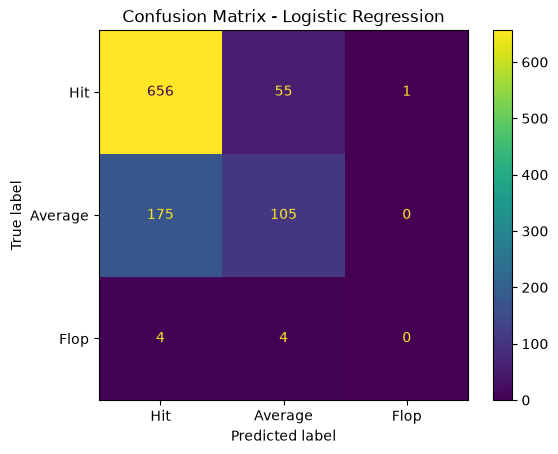

In [34]:
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_log,
    display_labels=["Hit", "Average", "Flop"])
disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

**Observation:** The Logistic Regression model correctly classified 656 Hit movies and 105 Average movies. However, it did not correctly classify any of the 8 Flop movies. Among the Average movies, 175 were incorrectly classified as Hit. Of the 8 Flop movies, 4 were predicted as Hit and 4 as Average. This indicates that the model performs considerably better for the majority Hit class, while the severe class imbalance limits its ability to identify the minority Flop class.

In [35]:
#Classification Report

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_log))


              precision    recall  f1-score   support

     average       0.64      0.38      0.47       280
        flop       0.00      0.00      0.00         8
         hit       0.79      0.92      0.85       712

    accuracy                           0.76      1000
   macro avg       0.48      0.43      0.44      1000
weighted avg       0.74      0.76      0.74      1000



Observation: The Logistic Regression model performs best for the Hit category, achieving a recall of 0.92 and an F1-score of 0.85. For the Average category, the model achieves a recall of 0.38 and an F1-score of 0.47, indicating that many Average movies are incorrectly classified as Hit. The model achieves 0 precision, recall, and F1-score for the Flop category, meaning that none of the 8 Flop movies in the test set were correctly identified.

Although the overall accuracy is 76.1%, the macro-average F1-score is only 0.44, showing that performance is not balanced across the three classes. This is mainly influenced by the severe class imbalance, particularly the very small number of Flop movies.

Decision Tree Classifier:


Decision Tree is a supervised machine learning algorithm used for classification and regression problems.
The model creates a tree-like structure by repeatedly splitting the data based on features that help separate the target classes.

In [36]:
#Training the Decision Tree Classifier

from sklearn.tree import DecisionTreeClassifier

In [37]:
dt_model = DecisionTreeClassifier(random_state=42)

In [38]:
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

In [39]:
y_pred_dt[:10]

array(['hit', 'average', 'hit', 'hit', 'hit', 'hit', 'average', 'average',
       'hit', 'average'], dtype=object)

In [40]:
# Decision Tree Model Evaluation

dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.73


**Observation:** The Decision Tree Classifier achieved an overall accuracy of 73.0% on the test dataset. This means that approximately 73% of the movie success categories were predicted correctly. However, because the target classes are highly imbalanced, accuracy alone is not sufficient to evaluate the model. Therefore, the confusion matrix and classification report are also examined to understand class-wise performance.

In [41]:
cm_dt = confusion_matrix(
    y_test,
    y_pred_dt,
    labels=["hit", "average", "flop"]
)


In [42]:
cm_dt

array([[594, 113,   5],
       [143, 135,   2],
       [  3,   4,   1]])

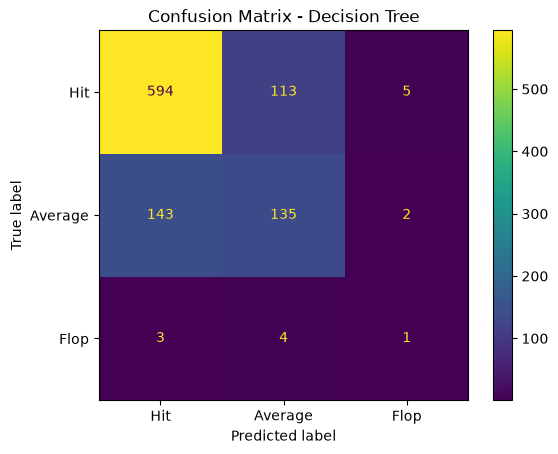

In [43]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_dt,
    display_labels=["Hit", "Average", "Flop"]
)

disp.plot()

plt.title("Confusion Matrix - Decision Tree")
plt.show()

**Observation:** The Decision Tree correctly classified 594 Hit movies, 135 Average movies, and 1 Flop movie. Among the 280 Average movies, 143 were incorrectly classified as Hit. Of the 8 Flop movies, 1 was correctly identified, while 3 were classified as Hit and 4 as Average. Compared with Logistic Regression, the Decision Tree identifies more Average movies and is able to identify one Flop movie, but it correctly classifies fewer Hit movies.

In [44]:
#Decision Tree Classification Report
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

     average       0.54      0.48      0.51       280
        flop       0.12      0.12      0.12         8
         hit       0.80      0.83      0.82       712

    accuracy                           0.73      1000
   macro avg       0.49      0.48      0.48      1000
weighted avg       0.72      0.73      0.73      1000



**Observation:** The model achieves an overall accuracy of 73.0%, with a macro-average F1-score of 0.48 and weighted-average F1-score of 0.73. The difference between the macro and weighted scores reflects the effect of the class imbalance on model performance.

“Logistic Regression achieved higher overall accuracy, but Decision Tree showed slightly better balanced class-wise performance based on macro F1 and was able to identify one Flop movie. This demonstrates why accuracy alone can be misleading for an imbalanced dataset.”

In [45]:
#Random Forest Classifier
#the Random Forest Classifier is used to predict whether a movie belongs to the Hit, Average, or Flop category.

from sklearn.ensemble import RandomForestClassifier

In [46]:
rf_model = RandomForestClassifier(n_estimators=100,random_state=42)
rf_model.fit(X_train,y_train)
y_pred_rf = rf_model.predict(X_test)
y_pred_rf[:20]

array(['hit', 'average', 'hit', 'hit', 'hit', 'average', 'average', 'hit',
       'hit', 'hit', 'hit', 'average', 'hit', 'hit', 'hit', 'hit', 'hit',
       'hit', 'hit', 'hit'], dtype=object)

In [47]:
#Random Forest Model Evaluation
#accuracy
rf_accuracy = accuracy_score(y_test,y_pred_rf)
print("RandomForestAccuracy:",rf_accuracy)

RandomForestAccuracy: 0.803


The Random Forest Classifier achieved an overall accuracy of 80.3% on the test dataset. This is higher than the accuracy obtained from Logistic Regression (76.1%) and Decision Tree (73.0%). However, since the target classes are highly imbalanced, accuracy alone does not provide a complete picture of model performance. Therefore, the confusion matrix and classification report are also evaluated to understand performance across the Hit, Average, and Flop categories.

In [48]:
# Random Forest Confusion Matrix

cm_rf = confusion_matrix(y_test,y_pred_rf,labels=["hit","average","flop"])
                         

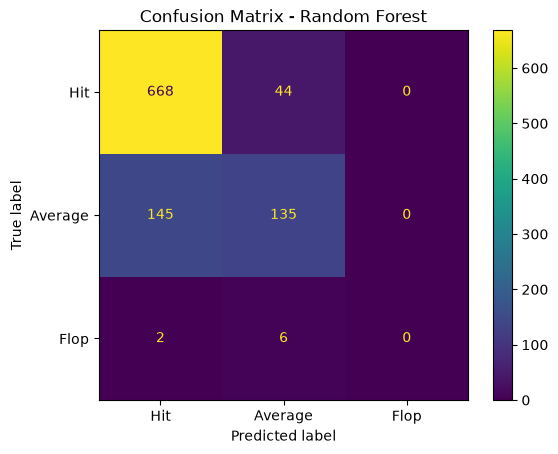

In [49]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["Hit", "Average", "Flop"])

disp.plot()
plt.title("Confusion Matrix - Random Forest")
plt.show()

**Observation:** The Random Forest Classifier correctly classified 668 Hit movies and 135 Average movies. However, it did not correctly identify any of the 8 Flop movies, and the model did not predict any movie as Flop. Of the 8 actual Flop movies, 2 were classified as Hit and 6 as Average. Although Random Forest achieved the highest overall accuracy among the three baseline models, its inability to identify the minority Flop class shows the effect of severe class imbalance

In [52]:
# Random Forest Classification Report

In [53]:
print(classification_report(
    y_test,
    y_pred_rf,
    zero_division=0
))

              precision    recall  f1-score   support

     average       0.73      0.48      0.58       280
        flop       0.00      0.00      0.00         8
         hit       0.82      0.94      0.87       712

    accuracy                           0.80      1000
   macro avg       0.52      0.47      0.49      1000
weighted avg       0.79      0.80      0.79      1000



**Observation:** The model achieved an overall accuracy of 80.3%, a macro-average F1-score of 0.49, and a weighted-average F1-score of 0.79. The lower macro F1-score compared with the weighted F1-score highlights the effect of class imbalance and shows that performance is not equally strong across all three movie success categories.

“Random Forest achieved the highest overall accuracy at 80.3% and the highest macro F1-score among the three baseline models at 0.49. However, it still failed to identify the minority Flop class. Decision Tree had lower overall accuracy but was the only baseline model to correctly identify a Flop movie.”

In [54]:
# Hyperparameter Tuning - Random Forest
#Import GridSearchCV


In [55]:
from sklearn.model_selection import GridSearchCV

In [63]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "class_weight": [None, "balanced"]
}

rf_tuning_model = RandomForestClassifier(
    random_state=42
)

grid_search = GridSearchCV(
    estimator=rf_tuning_model,
    param_grid=param_grid,
    cv=3,
    scoring="f1_macro",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'class_weight': [None, 'balanced'], 'max_depth': [10, 20, ...], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"ve

In [64]:
print("Best Parameters:")
print(grid_search.best_params_)

print("Best Cross-Validation Macro F1:")
print(grid_search.best_score_)

Best Parameters:
{'class_weight': 'balanced', 'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
Best Cross-Validation Macro F1:
0.5448026363275913


In [65]:
best_rf_model = grid_search.best_estimator_

In [66]:
y_pred_tuned_rf = best_rf_model.predict(X_test)

In [67]:
tuned_rf_accuracy = accuracy_score(y_test, y_pred_tuned_rf)

In [68]:
print("Tuned Random Forest Accuracy:", tuned_rf_accuracy)

Tuned Random Forest Accuracy: 0.779


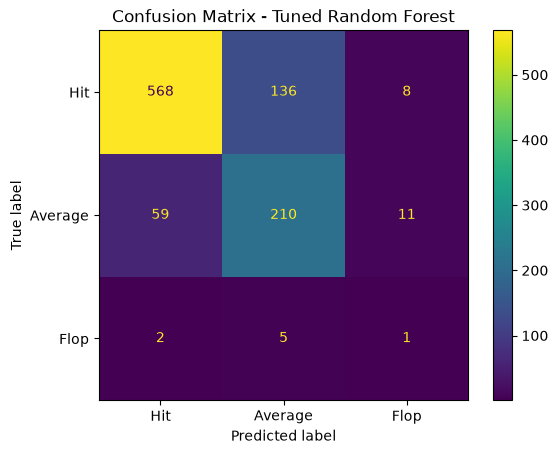

In [69]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

labels = ["hit", "average", "flop"]

cm_tuned_rf = confusion_matrix(
    y_test,
    y_pred_tuned_rf,
    labels=labels
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_tuned_rf,
    display_labels=["Hit", "Average", "Flop"]
)

disp.plot()
plt.title("Confusion Matrix - Tuned Random Forest")
plt.show()

**Observation:** After hyperparameter tuning, the Random Forest accuracy decreased from 80.3% to 77.9%. However, the tuned model showed better performance across the minority classes. It correctly predicted 210 out of 280 Average movies compared with 135 in the original Random Forest. It also correctly identified 1 out of 8 Flop movies, whereas the original model did not correctly identify any Flop movies. Correct Hit predictions decreased from 668 to 568. Therefore, tuning created a trade-off: overall accuracy decreased, but the model became more balanced in predicting the different movie success categories.

In [70]:
print(classification_report(
    y_test,
    y_pred_tuned_rf,
    zero_division=0
))

              precision    recall  f1-score   support

     average       0.60      0.75      0.67       280
        flop       0.05      0.12      0.07         8
         hit       0.90      0.80      0.85       712

    accuracy                           0.78      1000
   macro avg       0.52      0.56      0.53      1000
weighted avg       0.81      0.78      0.79      1000



**Observation**: 
The tuned Random Forest achieved an overall accuracy of 77.9%. The Average category improved to a recall of 0.75 and an F1-score of 0.67. The Hit category continued to perform strongly with a precision of 0.90, recall of 0.80, and F1-score of 0.85. The model also showed a small improvement for the Flop category, with recall increasing from 0.00 to 0.12 and F1-score from 0.00 to 0.07. The macro F1-score improved from 0.49 to 0.53, indicating better overall balance across the three classes, although Flop prediction remains weak because there are only 8 Flop movies in the test dataset.

In [71]:
#model comparison:

In [74]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Tuned Random Forest"
    ],
    
    "Accuracy": [
        log_accuracy,
        dt_accuracy,
        rf_accuracy,
        tuned_rf_accuracy
    ]
})

model_comparison


,Model,Accuracy
0,Logistic Regression,0.761
1,Decision Tree,0.730
2,Random Forest,0.803
3,Tuned Random Forest,0.779


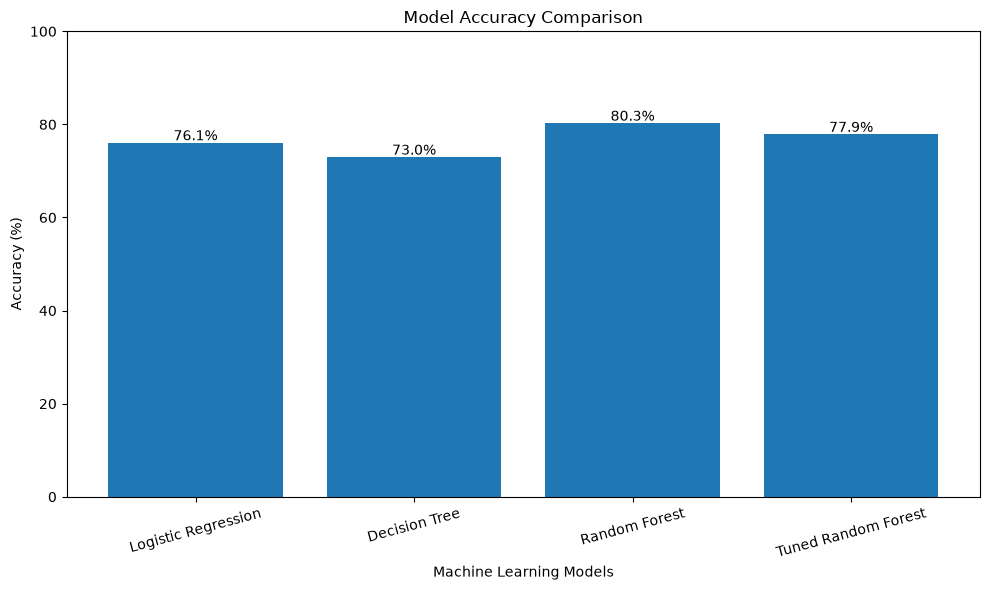

In [77]:
import matplotlib.pyplot as plt

models = [
    "Logistic Regression",
    "Decision Tree",
    "Random Forest",
    "Tuned Random Forest"
]

accuracy = [
   76.1,
    73.0,
    80.3,
    77.9]

plt.figure(figsize=(10, 6))

bars = plt.bar(models, accuracy)

for bar, value in zip(bars, accuracy):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        f"{value}%",
        ha="center"
    )

plt.title("Model Accuracy Comparison")
plt.xlabel("Machine Learning Models")
plt.ylabel("Accuracy (%)")

plt.ylim(0, 100)
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

** KEY FINDINGS**

The following key findings were observed during the project:


* The target variable was highly imbalanced. After data cleaning, the dataset contained 3,556 Hit movies, 1,401 Average movies, and only 41 Flop movies.

* Exploratory Data Analysis showed that IMDb scores were mostly concentrated between approximately 5 and 8.

* Movie duration showed some variation across the success categories. Hit movies had a median duration of approximately 107 minutes, compared with approximately 97 minutes for Average movies and 92 minutes for Flop movies.

* The budget variable contained extreme outliers, including a few unusually large values. Based on the original budget values, the median budgets were approximately $19.8 million for Hit movies, $20.0 million for Average movies, and $19.0 million for Flop movies. Since the median budgets were very similar, budget alone did not clearly distinguish between the three movie success categories.

* Gross revenue showed clearer differences between the movie success categories. The median gross revenue was approximately $27.30 million for Hit movies, $22.13 million for Average movies, and $9.11 million for Flop movies. This indicates that Hit movies generally generated higher gross revenue, while Flop movies had substantially lower median gross revenue.

* Correlation analysis identified a very strong positive correlation of approximately 0.95 between actor_1_facebook_likes and cast_total_facebook_likes, indicating possible multicollinearity. Therefore, actor_1_facebook_likes was removed from the model input.

* High-cardinality categorical features such as director name, actor names, and plot keywords were excluded from the final model input. The remaining categorical variables were converted into numerical form before model training.

  * After final feature selection, 19 input features were used for model building.

* Logistic Regression achieved an overall test accuracy of 76.1%.

* Decision Tree achieved an overall test accuracy of 73.0%.

* Random Forest achieved the highest overall accuracy of 80.3% among the untuned models.

* The original Random Forest performed particularly well for the majority Hit category but failed to correctly identify any of the 8 Flop movies in the test dataset.

* Hyperparameter tuning was performed on the Random Forest using GridSearchCV, with Macro F1-score as the scoring metric because the target classes were highly imbalanced.

* The Tuned Random Forest achieved an accuracy of 77.9%, which was slightly lower than the original Random Forest accuracy of 80.3%. However, its  Macro F1-score improved from 0.49 to 0.53.

* The Tuned Random Forest showed a substantial improvement in identifying Average movies. Correct Average predictions increased from 135 out of 280 in the original Random Forest to 210 out of 280 after tuning.

* The Tuned Random Forest also correctly identified 1 out of the 8 Flop movies, whereas the original Random Forest correctly identified none.
Overall, the results demonstrate that accuracy alone is not sufficient for evaluating an imbalanced classification problem. Precision, recall, F1-score, Macro F1-score, and the confusion matrix provide important additional information about performance across individual classes.

**Project Limitations**

* The dataset was highly imbalanced, with only 41 Flop movies, making it difficult for the models to learn and predict this category effectively.
* Although tuning improved class balance, Flop prediction remained weak because of the limited number of Flop observations.
* Some numerical features contained extreme or skewed values.
* Some features, such as gross revenue, user votes, and reviews, may contain post-release information. Therefore, the current model should not be considered a purely pre-release prediction system.
* Future improvements could focus on obtaining more balanced data and using more pre-release features.

In [80]:
##Conclusion

#This project developed an end-to-end machine learning classification model to classify movies into Hit, Average, and Flop categories based on IMDb score ranges. The project included data cleaning, exploratory data analysis, feature selection, categorical encoding, multicollinearity analysis, train-test splitting, feature scaling, model building, evaluation, and hyperparameter tuning.

#The EDA showed that budget alone did not clearly differentiate movie success categories. The median budgets were approximately $19.8 million for Hit movies, $20.0 million for Average movies, and $19.0 million for Flop movies, showing very little difference between the categories. In contrast, gross revenue showed a clearer relationship with movie success. Hit movies had the highest median gross revenue at approximately $27.30 million, followed by Average movies at $22.13 million, while Flop movies had a much lower median gross revenue of approximately $9.11 million.

#Among the models evaluated, Logistic Regression achieved 76.1% accuracy, Decision Tree achieved 73.0%, and Random Forest achieved the highest overall accuracy of 80.3%. After hyperparameter tuning, the Tuned Random Forest achieved 77.9% accuracy, while its Macro F1-score improved from 0.49 to 0.53. It also improved the prediction of Average movies and correctly identified 1 of the 8 Flop movies, whereas the original Random Forest identified none.

#Overall, the project shows that higher budget does not necessarily indicate greater movie success, while gross revenue showed a clearer association with the success categories in this dataset. It also demonstrates that accuracy alone is not sufficient when evaluating an imbalanced classification problem. Metrics such as precision, recall, F1-score, Macro F1-score, and the confusion matrix are important for understanding performance across all movie success categories.

#Future improvements could focus on obtaining a more balanced dataset, particularly more Flop observations, and using more pre-release features if the model is intended to predict movie success before release.
